In [2]:
import tensorflow as tf 
from tensorflow import keras

tf.__version__ #2.21.0
keras.__version__ #3.14.1

'3.14.1'

In [5]:
fashion_mist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
#Scale the dataset:
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

In [9]:
X_test = X_test/255.0

In [10]:
print(y_train[0])

4


In [11]:
class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal"]

In [12]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape = [28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),

])

c:\Users\Minh Son Tran\Desktop\Machine_Learning\ML_book\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
weight, bias = model.layers[1].get_weights()
print(weight)

[[ 0.04624959  0.05857015  0.05729972 ... -0.0233695  -0.00793374
   0.05192037]
 [-0.00574777  0.04349741 -0.00884459 ... -0.04110464  0.02330357
  -0.024278  ]
 [-0.06712385  0.04466345 -0.01715666 ...  0.06284674 -0.00285092
   0.02818538]
 ...
 [ 0.05788781 -0.0107068  -0.00496256 ... -0.01228235  0.00748834
   0.00171968]
 [-0.01606232 -0.01636031  0.05668242 ...  0.02855092  0.00345773
   0.01661464]
 [ 0.01754655 -0.02492497 -0.07139969 ...  0.03932051  0.07086717
   0.00068288]]


In [18]:
model.compile(loss = "sparse_categorical_crossentropy", optimizer="sgd", metrics = ["accuracy"])


In [19]:
history = model.fit(X_train, y_train, epochs = 10, validation_data = (X_valid, y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7697 - loss: 0.7090 - val_accuracy: 0.8324 - val_loss: 0.4959
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8304 - loss: 0.4875 - val_accuracy: 0.8520 - val_loss: 0.4433
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8445 - loss: 0.4431 - val_accuracy: 0.8508 - val_loss: 0.4376
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8542 - loss: 0.4157 - val_accuracy: 0.8598 - val_loss: 0.4034
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8617 - loss: 0.3962 - val_accuracy: 0.8658 - val_loss: 0.3903
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8677 - loss: 0.3804 - val_accuracy: 0.8650 - val_loss: 0.3851
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8709 - loss: 0.3668 - val_accuracy: 0.8656 - val_loss: 0.3817
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8753 - loss: 0.3549 - 

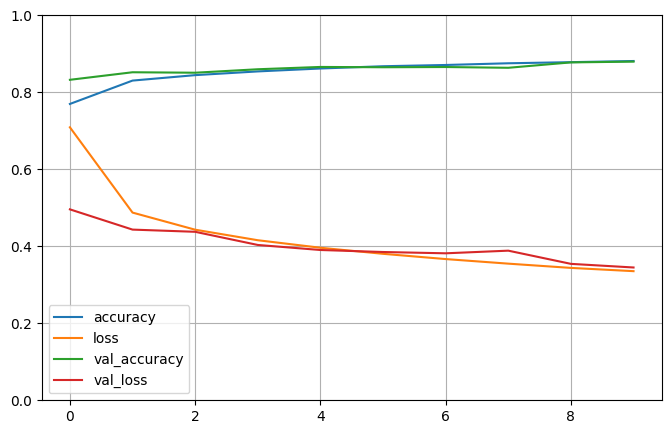

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()